# IY028 - Poster Figures Preparation

Plots class-mean ± SEM time series for both mCherry and GFP channels using the **old** paired dataset:

`EXP-25-IY008/4_transformed_exp_time_series`

Classes are defined as TF × glucose condition (6 classes: Nrg1 and Rtg1 each under 2%, 0.1%, and 0.01% glucose). This mirrors the `_NEW` trace overview but for the original curated file pairs.

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer


def find_project_root(start=None):
    """Find the repository root by walking up from the current directory."""
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "experiments").exists():
            return candidate
    raise RuntimeError("Could not find stochastic_simulations project root.")


PROJECT_ROOT = find_project_root()
EXP_DIR = PROJECT_ROOT / "experiments"
IY028_DIR = EXP_DIR / "EXP-26-IY028"
DATA_DIR = EXP_DIR / "EXP-25-IY008" / "4_transformed_exp_time_series"
SRC_DIR = PROJECT_ROOT / "src"
sys.path.insert(0, str(SRC_DIR.resolve()))

RANDOM_STATE = 42
META_COLS = ["id", "group", "experiment"]

np.random.seed(RANDOM_STATE)
plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})
sns.set_theme(style="whitegrid", palette="colorblind")

print(f"Project root : {PROJECT_ROOT}")
print(f"Data dir OK  : {DATA_DIR.exists()} -> {DATA_DIR}")

Project root : /home/ianyang/stochastic_simulations
Data dir OK  : True -> /home/ianyang/stochastic_simulations/experiments/EXP-25-IY008/4_transformed_exp_time_series


## 1. Load Old Paired Data

In [3]:
# Each entry: (mCherry_stem, GFP_stem, label, glucose_pct, TF)
# 6 classes: Nrg1 × {2%, 0.1%, 0.01%} and Rtg1 × {2%, 0.1%, 0.01%}
# Exclusions: 19554 (Mig1/unknown TFs), 19566/group_1344 (ambiguous TF), Cat8 (only 2 of 3 conditions)
FILE_PAIRS = [
    # Nrg1 strain (group 1346)
    ("19316_2020_10_26_steadystate_glucose_144m_2w2_00_group_1346_4_mCherry_time_series",
     "19316_2020_10_26_steadystate_glucose_144m_2w2_00_group_1346_4_GFP_time_series",
     0, "2%",    "Nrg1"),
    ("19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01_group_1346_mCherry_time_series",
     "19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01_group_1346_GFP_time_series",
     1, "0.1%",  "Nrg1"),
    ("20213_2021_09_07_steady_0p01glc_1344_1346_1347_00_group_1346_mCherry_time_series",
     "20213_2021_09_07_steady_0p01glc_1344_1346_1347_00_group_1346_GFP_time_series",
     2, "0.01%", "Nrg1"),
    # Rtg1 strain (group 1347)
    ("19316_2020_10_26_steadystate_glucose_144m_2w2_00_group_1347_mCherry_time_series",
     "19316_2020_10_26_steadystate_glucose_144m_2w2_00_group_1347_GFP_time_series",
     3, "2%",    "Rtg1"),
    ("19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01_group_1347_mCherry_time_series",
     "19566_2020_12_07_steadystate_glucose_1344m_2w0p1_01_group_1347_GFP_time_series",
     4, "0.1%",  "Rtg1"),
    ("20213_2021_09_07_steady_0p01glc_1344_1346_1347_00_group_1347_mCherry_time_series",
     "20213_2021_09_07_steady_0p01glc_1344_1346_1347_00_group_1347_GFP_time_series",
     5, "0.01%", "Rtg1"),
]

LABEL_NAMES = {
    0: "Nrg1 @ 2% glc",
    1: "Nrg1 @ 0.1% glc",
    2: "Nrg1 @ 0.01% glc",
    3: "Rtg1 @ 2% glc",
    4: "Rtg1 @ 0.1% glc",
    5: "Rtg1 @ 0.01% glc",
}

all_m, all_g, all_y = [], [], []

for mc_stem, gfp_stem, label, glc, tf in FILE_PAIRS:
    df_m = pd.read_csv(DATA_DIR / f"{mc_stem}.csv")
    df_g = pd.read_csv(DATA_DIR / f"{gfp_stem}.csv")

    tc_m = [c for c in df_m.columns if c not in META_COLS]
    tc_g = [c for c in df_g.columns if c not in META_COLS]

    common = sorted(set(df_m["id"]) & set(df_g["id"]))
    df_m = df_m[df_m["id"].isin(common)].set_index("id").loc[common]
    df_g = df_g[df_g["id"].isin(common)].set_index("id").loc[common]

    all_m.append(df_m[tc_m].to_numpy(float))
    all_g.append(df_g[tc_g].to_numpy(float))
    all_y.extend([label] * len(common))
    print(f"  {tf} @ {glc:>5s} glc — {len(common):4d} paired cells  "
          f"[mCherry: {len(tc_m)} tp, GFP: {len(tc_g)} tp]")

min_tp_m = min(a.shape[1] for a in all_m)
min_tp_g = min(a.shape[1] for a in all_g)

X_m_raw = np.vstack([a[:, :min_tp_m] for a in all_m])
X_g_raw = np.vstack([a[:, :min_tp_g] for a in all_g])
y_raw = np.array(all_y, dtype=int)

print(f"\nmCherry matrix: {X_m_raw.shape} ({min_tp_m} timepoints)")
print(f"GFP matrix    : {X_g_raw.shape} ({min_tp_g} timepoints)")
for lbl, name in LABEL_NAMES.items():
    print(f"  {lbl}: {name:22s} → {np.sum(y_raw == lbl):4d} cells")

  Nrg1 @    2% glc —   84 paired cells  [mCherry: 128 tp, GFP: 232 tp]
  Nrg1 @  0.1% glc —  231 paired cells  [mCherry: 135 tp, GFP: 219 tp]
  Nrg1 @ 0.01% glc —  231 paired cells  [mCherry: 105 tp, GFP: 104 tp]
  Rtg1 @    2% glc —   78 paired cells  [mCherry: 126 tp, GFP: 146 tp]
  Rtg1 @  0.1% glc —  200 paired cells  [mCherry: 117 tp, GFP: 80 tp]
  Rtg1 @ 0.01% glc —  275 paired cells  [mCherry: 89 tp, GFP: 165 tp]

mCherry matrix: (1099, 89) (89 timepoints)
GFP matrix    : (1099, 80) (80 timepoints)
  0: Nrg1 @ 2% glc          →   84 cells
  1: Nrg1 @ 0.1% glc        →  231 cells
  2: Nrg1 @ 0.01% glc       →  231 cells
  3: Rtg1 @ 2% glc          →   78 cells
  4: Rtg1 @ 0.1% glc        →  200 cells
  5: Rtg1 @ 0.01% glc       →  275 cells


## 2. Preprocessing: NaN Imputation and Class Balancing

In [4]:
def fill_nans(X, random_state=42):
    """Impute missing cell-trace values with a deterministic IterativeImputer."""
    X_arr = np.asarray(X, dtype=float)
    original_shape = X_arr.shape
    X_filled = np.atleast_2d(X_arr).copy()
    if not np.isnan(X_filled).any():
        return X_filled.reshape(original_shape)

    all_nan_cols = np.isnan(X_filled).all(axis=0)
    if all_nan_cols.any():
        finite_values = X_filled[np.isfinite(X_filled)]
        fill_value = float(np.nanmean(finite_values)) if finite_values.size else 0.0
        X_filled[:, all_nan_cols] = fill_value

    imputer = IterativeImputer(max_iter=10, tol=1e-3, initial_strategy="mean", random_state=random_state)
    X_imputed = imputer.fit_transform(X_filled)

    if np.isnan(X_imputed).any():
        col_medians = np.nanmedian(X_imputed, axis=0)
        global_median = float(np.nanmedian(X_imputed)) if np.isfinite(X_imputed).any() else 0.0
        col_medians = np.where(np.isfinite(col_medians), col_medians, global_median)
        nan_mask = np.isnan(X_imputed)
        X_imputed[nan_mask] = np.take(col_medians, np.where(nan_mask)[1])

    return X_imputed.reshape(original_shape)


def balance_by_label(X_m, X_g, y, random_state=42):
    """Subsample every class to the minority class size."""
    rng = np.random.default_rng(random_state)
    min_count = min(np.sum(y == lbl) for lbl in np.unique(y))
    keep_idx = np.sort(np.concatenate([
        rng.choice(np.where(y == lbl)[0], size=min_count, replace=False)
        for lbl in sorted(np.unique(y))
    ]))
    return X_m[keep_idx], X_g[keep_idx], y[keep_idx]


X_m_clean = fill_nans(X_m_raw)
X_g_clean = fill_nans(X_g_raw)
X_m_bal, X_g_bal, y_bal = balance_by_label(X_m_clean, X_g_clean, y_raw, RANDOM_STATE)
class_names = [LABEL_NAMES[i] for i in sorted(LABEL_NAMES)]

print(f"NaNs after fill: mCherry={np.isnan(X_m_clean).sum()}, GFP={np.isnan(X_g_clean).sum()}")
print(f"Balanced cells : {len(y_bal)}")
for lbl, name in LABEL_NAMES.items():
    print(f"  {name:22s} → {np.sum(y_bal == lbl):4d} cells")

NaNs after fill: mCherry=0, GFP=0
Balanced cells : 468
  Nrg1 @ 2% glc          →   78 cells
  Nrg1 @ 0.1% glc        →   78 cells
  Nrg1 @ 0.01% glc       →   78 cells
  Rtg1 @ 2% glc          →   78 cells
  Rtg1 @ 0.1% glc        →   78 cells
  Rtg1 @ 0.01% glc       →   78 cells


## 3. Trace Overview: Class Mean ± SEM

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY028/IY028_trace_overview_exp_data_dual.png


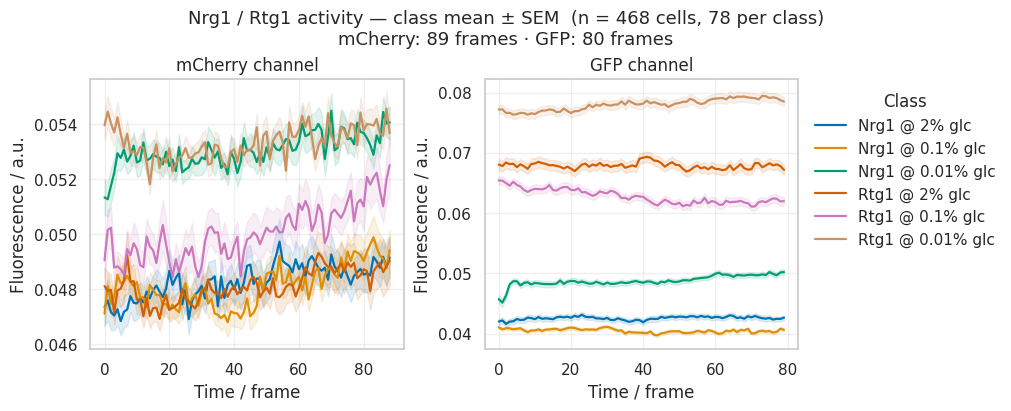

In [5]:
palette = sns.color_palette("colorblind", n_colors=len(class_names))
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

for label, class_name in enumerate(class_names):
    mask = y_bal == label
    color = palette[label]

    m_mean = X_m_bal[mask].mean(axis=0)
    m_sem  = X_m_bal[mask].std(axis=0, ddof=1) / np.sqrt(mask.sum())
    g_mean = X_g_bal[mask].mean(axis=0)
    g_sem  = X_g_bal[mask].std(axis=0, ddof=1) / np.sqrt(mask.sum())

    axes[0].plot(np.arange(min_tp_m), m_mean, label=class_name, color=color, linewidth=1.6)
    axes[0].fill_between(np.arange(min_tp_m), m_mean - m_sem, m_mean + m_sem, color=color, alpha=0.12)
    axes[1].plot(np.arange(min_tp_g), g_mean, label=class_name, color=color, linewidth=1.6)
    axes[1].fill_between(np.arange(min_tp_g), g_mean - g_sem, g_mean + g_sem, color=color, alpha=0.12)

axes[0].set_title("mCherry channel")
axes[1].set_title("GFP channel")
for ax in axes:
    ax.set_xlabel("Time / frame")
    ax.set_ylabel("Fluorescence / a.u.")
    ax.grid(alpha=0.3)

axes[1].legend(bbox_to_anchor=(1.01, 1), loc="best", frameon=False, title="Class")

n_cells = len(y_bal)
n_per_class = n_cells // len(class_names)
fig.suptitle(
    f"Nrg1 / Rtg1 activity — class mean ± SEM  "
    f"(n = {n_cells} cells, {n_per_class} per class)\n"
    f"mCherry: {min_tp_m} frames · GFP: {min_tp_g} frames",
    fontsize=13,
)

out_path = IY028_DIR / "IY028_trace_overview_exp_data_dual.png"
fig.savefig(out_path, dpi=300, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()

## 4. Model Accuracy Comparison: Old (6-class) vs NEW (12-class) Data

Bar chart comparing test accuracies across three model types for both datasets.

Accuracy values sourced from:
- **Old data:** `IY021_catch22_svm_exp_data_dual.ipynb` (Raw SVM, Catch22+SVM), `IY021_test_simclr_exp_data_dual.ipynb` (SimCLR best)
- **New data:** `IY028_catch22_svm_dual_NEW_results.csv` (Raw SVM, Catch22+SVM), `IY028_test_simclr_exp_data_dual_NEW.ipynb` (SimCLR best)

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY028/IY028_model_accuracy_comparison.png


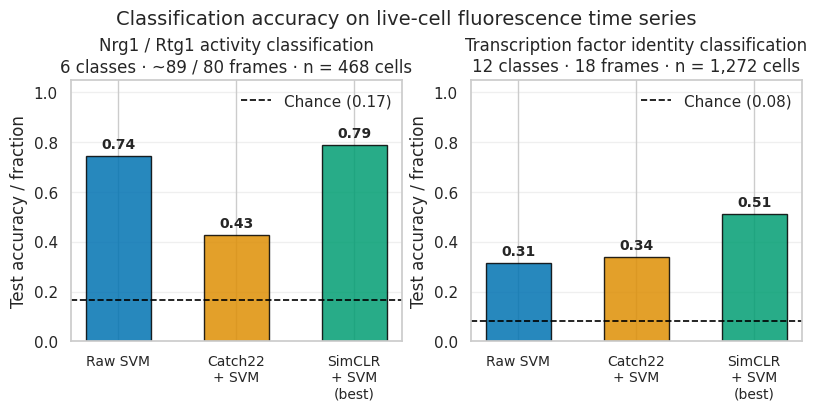

In [6]:
# Test accuracies sourced from:
#   6-class (Nrg1/Rtg1 × glucose, ~89/80 frames, 468 cells balanced):
#     Raw SVM=0.7447, Catch22+SVM=0.4255  ← IY021_catch22_svm_exp_data_dual
#     SimCLR best=0.7872                  ← IY021_test_simclr_exp_data_dual
#   12-class (TF identity, 18 frames, 1272 cells balanced):
#     Raw SVM=0.3137, Catch22+SVM=0.3373  ← IY028_catch22_svm_dual_NEW_results.csv
#     SimCLR best=0.5098                  ← IY028_test_simclr_exp_data_dual_NEW
model_labels = ["Raw SVM", "Catch22\n+ SVM", "SimCLR\n+ SVM\n(best)"]
old_accs = [0.7447, 0.4255, 0.7872]
new_accs = [0.3137, 0.3373, 0.5098]
chance_old = 1 / 6
chance_new = 1 / 12

palette = sns.color_palette("colorblind")
bar_colors = [palette[0], palette[1], palette[2]]

x = np.arange(len(model_labels))
width = 0.55

fig, axes = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)

panel_specs = [
    (axes[0], old_accs, chance_old,
     "Nrg1 / Rtg1 activity classification\n"
     "6 classes · ~89 / 80 frames · n = 468 cells"),
    (axes[1], new_accs, chance_new,
     "Transcription factor identity classification\n"
     "12 classes · 18 frames · n = 1,272 cells"),
]
for ax, accs, chance, title in panel_specs:
    bars = ax.bar(x, accs, width=width, color=bar_colors, alpha=0.85, edgecolor="black")
    ax.axhline(chance, color="black", linestyle="--", linewidth=1.2,
               label=f"Chance ({chance:.2f})")
    ax.set_xticks(x)
    ax.set_xticklabels(model_labels, fontsize=10)
    ax.set_ylabel("Test accuracy / fraction")
    ax.set_ylim(0, 1.05)
    ax.set_title(title, fontsize=12)
    ax.legend(bbox_to_anchor=(1.01, 1), loc="best", frameon=False)
    ax.grid(axis="y", alpha=0.3)
    for bar, acc in zip(bars, accs):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"{acc:.2f}",
            ha="center", va="bottom", fontsize=10, fontweight="bold",
        )
    

fig.suptitle("Classification accuracy on live-cell fluorescence time series", fontsize=14)

out_path = IY028_DIR / "IY028_model_accuracy_comparison.png"
fig.savefig(out_path, dpi=300, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()

## 5. SimCLR Training Data: Positive Pair Example

The SimCLR encoder is pre-trained on stochastic telegraph-model simulations. Each training sample is a **positive pair** (x₁, x₂): two independent realisations of the same parameter set (same mean expression, autocorrelation time, and noise level). The model learns to embed these into nearby points in latent space despite their stochastic differences.

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY028/IY028_simclr_training_pair_example.png


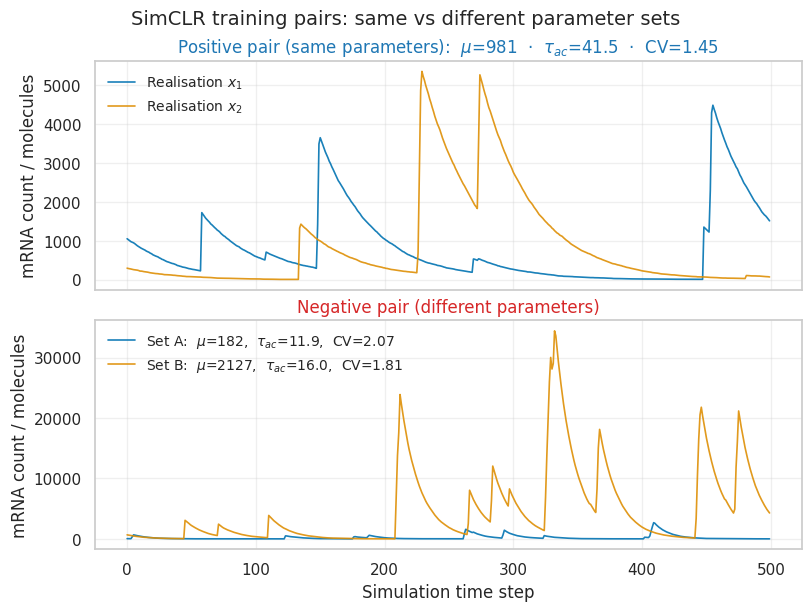

In [7]:
TRAIN_DATA_DIR = PROJECT_ROOT / "experiments" / "EXP-26-IY020" / "data"
PARAMS_CSV     = TRAIN_DATA_DIR / "IY020_simulation_parameters_sobol.csv"
SAMPLE_LEN     = 500  # matches sample_len used during SimCLR training

df_params = pd.read_csv(PARAMS_CSV)
good = df_params[df_params["success"] == True].reset_index(drop=True)

def load_two_trajs(row, rng, sample_len=SAMPLE_LEN):
    """Return two random trajectories from a parameter-set npz file."""
    npz = TRAIN_DATA_DIR / row["trajectory_filename"].replace(".csv", ".npz")
    trajs = list(np.load(npz, allow_pickle=True)["trajectories"])
    i1, i2 = rng.choice(len(trajs), size=2, replace=False)
    return (np.array(trajs[i1], dtype=float)[:sample_len],
            np.array(trajs[i2], dtype=float)[:sample_len])

rng = np.random.default_rng(42)

# ── Positive pair: two realisations from the SAME parameter set ──────────────
# Row 203: μ=981, τ=41.5, CV=1.45 — clear burst-and-decay telegraph dynamics
row_pos = good.iloc[203]
x1, x2 = load_two_trajs(row_pos, rng)
mu_p, tac_p, cv_p = row_pos["mu_target"], row_pos["t_ac_target"], row_pos["cv_target"]

# ── Negative pair: one realisation each from TWO DIFFERENT parameter sets ────
# Row 100: μ=182, τ=11.9, CV=2.07 — low mean, fast noisy switching
# Row 115: μ=2127, τ=16.0, CV=1.81 — high mean, rapid switching
row_a, row_b = good.iloc[100], good.iloc[115]
xa, _ = load_two_trajs(row_a, rng)
xb, _ = load_two_trajs(row_b, rng)
mu_a, tac_a, cv_a = row_a["mu_target"], row_a["t_ac_target"], row_a["cv_target"]
mu_b, tac_b, cv_b = row_b["mu_target"], row_b["t_ac_target"], row_b["cv_target"]

t = np.arange(SAMPLE_LEN)
palette = sns.color_palette("colorblind")
c1, c2 = palette[0], palette[1]

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True, constrained_layout=True)

# — Top: positive pair ———————————————————————————————————————————————————————
axes[0].plot(t, x1, color=c1, linewidth=1.2, alpha=0.9, label="Realisation $x_1$")
axes[0].plot(t, x2, color=c2, linewidth=1.2, alpha=0.9, label="Realisation $x_2$")
axes[0].set_ylabel("mRNA count / molecules")
axes[0].set_title(
    rf"Positive pair (same parameters):  $\mu$={mu_p:.0f}  ·  $\tau_{{ac}}$={tac_p:.1f}  ·  CV={cv_p:.2f}",
    fontsize=12,
    color="tab:blue",
)
axes[0].legend(loc="best", fontsize=10, frameon=False)
axes[0].grid(alpha=0.3)

# — Bottom: negative pair ——————————————————————————————————————————————————————
axes[1].plot(t, xa, color=c1, linewidth=1.2, alpha=0.9,
             label=rf"Set A:  $\mu$={mu_a:.0f},  $\tau_{{ac}}$={tac_a:.1f},  CV={cv_a:.2f}")
axes[1].plot(t, xb, color=c2, linewidth=1.2, alpha=0.9,
             label=rf"Set B:  $\mu$={mu_b:.0f},  $\tau_{{ac}}$={tac_b:.1f},  CV={cv_b:.2f}")
axes[1].set_xlabel("Simulation time step")
axes[1].set_ylabel("mRNA count / molecules")
axes[1].set_title("Negative pair (different parameters)", fontsize=12, color="tab:red")
axes[1].legend(loc="best", fontsize=10, frameon=False)
axes[1].grid(alpha=0.3)

fig.suptitle("SimCLR training pairs: same vs different parameter sets", fontsize=14)

out_path = IY028_DIR / "IY028_simclr_training_pair_example.png"
fig.savefig(out_path, dpi=300, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()

## 6. Embedding Space Visualisation: Catch22 vs SimCLR (t-SNE)

t-SNE projections of the catch22 feature space and the frozen SimCLR embedding space for paired dual-channel live-cell data (Nrg1 / Rtg1, three glucose concentrations each). Coordinates loaded from the pre-computed CSV; metrics (D-score, ARI, NMI) are computed on the full high-dimensional representations before dimensionality reduction.

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY028/IY028_poster_embedding_tsne.png


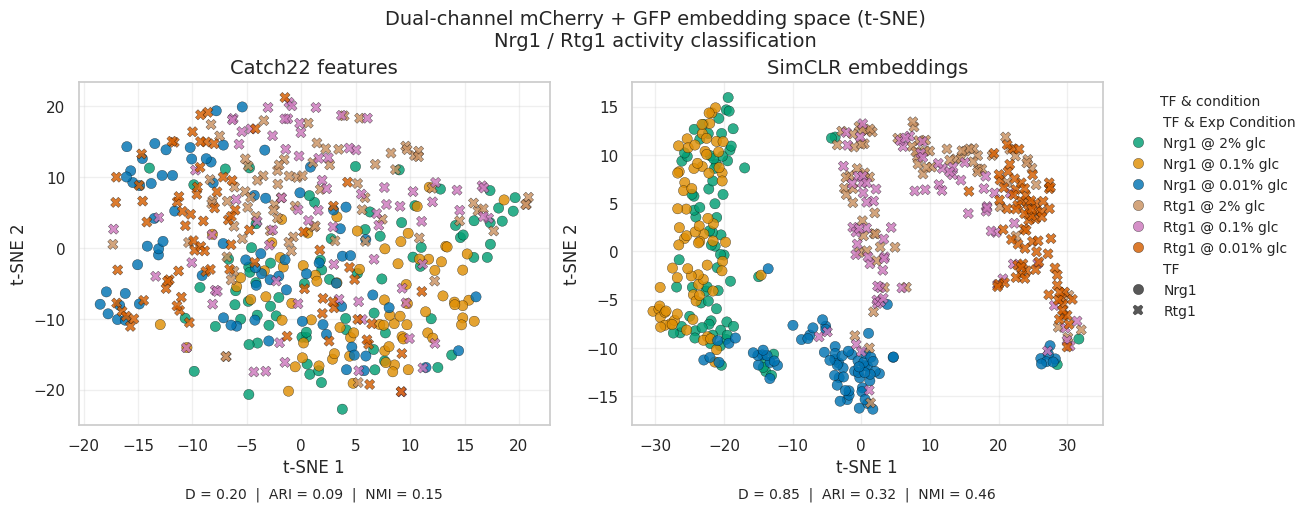

In [8]:
coords_df = pd.read_csv(IY028_DIR / "IY028_embedding_space_coordinates.csv")

# Metric values computed on the full high-dimensional representations (pre-reduction).
METRICS = {
    "catch22": dict(D_score=0.20, ARI=0.089, NMI=0.15),
    "SimCLR":  dict(D_score=0.85, ARI=0.32,  NMI=0.46),
}

# Rename class labels and representations for poster readability.
CLASS_RENAMES = {
    "Nrg1 @ 2% glucose":    "Nrg1 @ 2% glc",
    "Nrg1 @ 0.1% glucose":  "Nrg1 @ 0.1% glc",
    "Nrg1 @ 0.01% glucose": "Nrg1 @ 0.01% glc",
    "Rtg1 @ 2% glucose":    "Rtg1 @ 2% glc",
    "Rtg1 @ 0.1% glucose":  "Rtg1 @ 0.1% glc",
    "Rtg1 @ 0.01% glucose": "Rtg1 @ 0.01% glc",
}
coords_df["TF & Exp Condition"] = coords_df["class_name"].replace(CLASS_RENAMES)
coords_df["TF"] = coords_df["tf"]

PANEL_TITLES = {"catch22": "Catch22 features", "SimCLR": "SimCLR embeddings"}
REPS = ["catch22", "SimCLR"]

# Colorblind-safe palette: one hue per class, marker style separates TFs.
n_classes = coords_df["TF & Exp Condition"].nunique()
palette = dict(zip(sorted(coords_df["TF & Exp Condition"].unique()),
                   sns.color_palette("colorblind", n_colors=n_classes)))
markers = {"Nrg1": "o", "Rtg1": "X"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

for ax, rep in zip(axes, REPS):
    df_sub = coords_df[(coords_df["representation"] == rep) & (coords_df["method"] == "t-SNE")]
    sns.scatterplot(
        data=df_sub, x="x", y="y",
        hue="TF & Exp Condition", style="TF",
        palette=palette, markers=markers,
        s=55, alpha=0.82, linewidth=0.25, edgecolor="black",
        ax=ax, legend=(ax is axes[-1]),
    )
    ax.set_title(PANEL_TITLES[rep], fontsize=14)
    ax.set_xlabel("t-SNE 1", fontsize=12)
    ax.set_ylabel("t-SNE 2", fontsize=12)
    ax.grid(alpha=0.3)
    # Metrics as a clean annotation below each panel.
    m = METRICS[rep]
    ax.text(0.5, -0.18,
            f"D = {m['D_score']:.2f}  |  ARI = {m['ARI']:.2f}  |  NMI = {m['NMI']:.2f}",
            transform=ax.transAxes, ha="center", va="top", fontsize=10, clip_on=False)

axes[-1].legend(bbox_to_anchor=(1.02, 1), loc="best", frameon=False,
                fontsize=10, title="TF & condition", title_fontsize=10)
fig.suptitle(
    "Dual-channel mCherry + GFP embedding space (t-SNE)\n"
    "Nrg1 / Rtg1 activity classification",
    fontsize=14,
)

out_path = IY028_DIR / "IY028_poster_embedding_tsne.png"
fig.savefig(out_path, dpi=300, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()

## 7. Pairwise Same/Different: Method Comparison

Comparison of all classification methods on the pairwise same/different task across four stochastic statistics, at two fold-variation magnitudes. Each bar is test accuracy; chance is 50%.

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY028/IY028_poster_pairwise_comparison.png


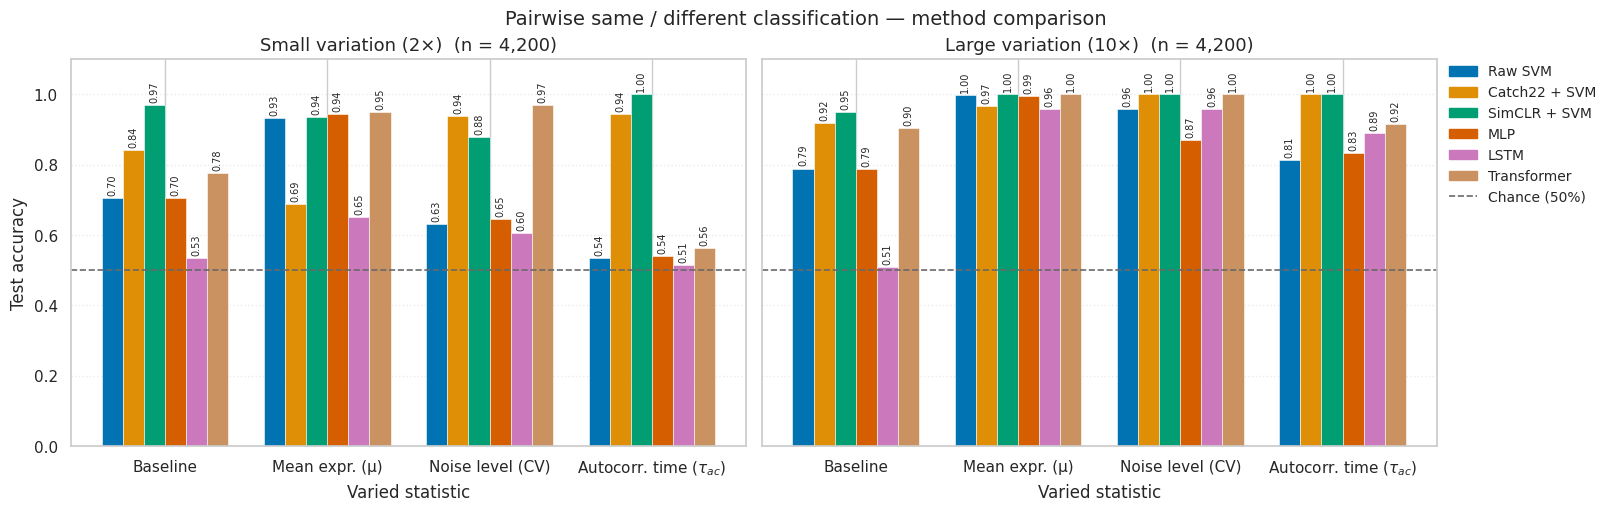

In [12]:
import json as _json

IY025_DIR = PROJECT_ROOT / "experiments" / "EXP-26-IY025"
IY029_DIR = PROJECT_ROOT / "experiments" / "EXP-26-IY029"

# Poster-readable axis labels for the four varied statistics.
DS_NAMES     = ["Baseline", "Mu", "CV", "T_ac"]
DS_LABELS    = ["Baseline", "Mean expr. (μ)", "Noise level (CV)", "Autocorr. time ($τ_{ac}$)"]
KEY_MAP      = {"baseline": "Baseline", "mu": "Mu", "cv": "CV", "t_ac": "T_ac"}
# Poster-readable fold labels — no experiment numbers.
FOLDS        = [("iy011", "Small variation (2×)"), ("iy014", "Large variation (10×)")]
N_SAMPLES    = {"iy011": 4200, "iy014": 4200}  # pre-computed; consistent across conditions


def _load_flat(path, key_remap=None):
    raw = _json.loads(Path(path).read_text())
    return ({key_remap[k]: v for k, v in raw.items() if k in key_remap}
            if key_remap else raw)


def _load_iy025(path):
    raw = _json.loads(Path(path).read_text())
    return {KEY_MAP[ds]: {"iy011": raw["iy011"][ds], "iy014": raw["iy014"][ds]}
            for ds in raw["iy011"]}


def _load_simclr_best(path):
    d = _json.loads(Path(path).read_text())
    return d["results"][d["best_label"]]


raw_svm_data     = _load_iy025(IY025_DIR / "IY025_svm_pairwise_results.json")
catch22_data     = _load_flat(IY029_DIR / "IY029_catch22_svm_pairwise_results.json")
mlp_data         = _load_flat(IY029_DIR / "IY029_mlp_pairwise_results.json")
transformer_data = _load_flat(IY029_DIR / "IY029_transformer_pairwise_results.json")
lstm_data        = _load_flat(IY029_DIR / "IY029_lstm_pairwise_results.json")
simclr_data      = _load_simclr_best(IY029_DIR / "IY029_simclr_svm_pairwise_results.json")

METHODS = [
    ("Raw SVM",       raw_svm_data),
    ("Catch22 + SVM", catch22_data),
    ("SimCLR + SVM",  simclr_data),
    ("MLP",           mlp_data),
    ("LSTM",          lstm_data),
    ("Transformer",   transformer_data),
]

palette   = sns.color_palette("colorblind", n_colors=len(METHODS))
n_methods = len(METHODS)
n_ds      = len(DS_NAMES)
width     = 0.13
offsets   = np.linspace(-(n_methods - 1) / 2 * width,
                         (n_methods - 1) / 2 * width, n_methods)
x         = np.arange(n_ds)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True, constrained_layout=True)

for ax, (fold_key, fold_title) in zip(axes, FOLDS):
    for j, (label, data) in enumerate(METHODS):
        accs = [data[ds][fold_key] for ds in DS_NAMES]
        bars = ax.bar(x + offsets[j], accs, width=width,
                      color=palette[j], label=label,
                      edgecolor="white", linewidth=0.4)
        ax.bar_label(bars, fmt="%.2f", padding=2,
                     fontsize=7, rotation=90, label_type="edge")

    ax.axhline(0.5, color="dimgrey", linestyle="--", linewidth=1.2, label="Chance (50%)")
    ax.set_xticks(x)
    ax.set_xticklabels(DS_LABELS, fontsize=11)
    ax.set_xlabel("Varied statistic", fontsize=12)
    ax.set_ylim(0, 1.10)
    ax.set_title(f"{fold_title}  (n = {N_SAMPLES[fold_key]:,})", fontsize=13)
    ax.grid(axis="y", linestyle=":", alpha=0.4)

axes[0].set_ylabel("Test accuracy", fontsize=12)

import matplotlib.patches as mpatches
legend_handles = [
    mpatches.Patch(color=palette[j], label=label)
    for j, (label, _) in enumerate(METHODS)
] + [plt.Line2D([0], [0], color="dimgrey", linestyle="--", linewidth=1.2, label="Chance (50%)")]
axes[1].legend(handles=legend_handles, fontsize=10,
               bbox_to_anchor=(1.01, 1), loc="best", borderaxespad=0, frameon=False)

fig.suptitle("Pairwise same / different classification — method comparison", fontsize=14)

out_path = IY028_DIR / "IY028_poster_pairwise_comparison.png"
fig.savefig(out_path, dpi=300, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()

## 8. SimCLR Training Parameter Space (Sobol Sampling)

The SimCLR encoder was pre-trained on 1,024 unique telegraph-model parameter sets, each simulated with 1,000 independent realisations (655 sets used for training, 164 validation, 205 test). Parameter sets were drawn using **Sobol quasi-random sampling** to ensure near-uniform coverage of the 3D space (μ × τ × CV). Plotted below are all 1,024 sampled points.

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY028/IY028_poster_sobol_parameter_space.png


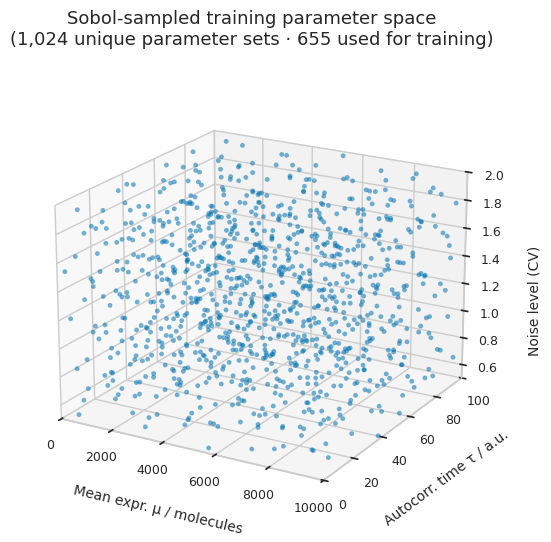


Training data summary:
  Total parameter sets : 1,024
  Training sets        : 655  (× 1,000 trajectories = 655,000 training trajectories)
  Validation sets      : 164
  Test sets            : 205


In [10]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from scipy.stats import qmc

N_SOBOL = 1024  # 2^10 — exact training set size
sobol = qmc.Sobol(d=3, scramble=True, seed=42)
U = sobol.random_base2(10)  # shape (1024, 3), values in [0, 1)

mu_vals  = qmc.scale(U[:, 0:1], [1],   [10_000]).flatten()
tac_vals = qmc.scale(U[:, 1:2], [0.5], [100]).flatten()
cv_vals  = qmc.scale(U[:, 2:3], [0.5], [2.0]).flatten()

color = sns.color_palette("colorblind")[0]

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(mu_vals, tac_vals, cv_vals,
           s=12, alpha=0.55, color=color, edgecolors="none")

ax.view_init(elev=20, azim=-60)

ax.set_xlabel("Mean expr. μ / molecules", fontsize=10, labelpad=12)
ax.set_ylabel("Autocorr. time τ / a.u.", fontsize=10, labelpad=12)

# ax.set_zlabel is unreliable in 3D across view angles; use text2D anchored to
# axes coordinates instead — position (1.08, 0.5) sits just right of the z ticks.
ax.set_zlabel("")
ax.text2D(1.08, 0.5, "Noise level (CV)", transform=ax.transAxes,
          fontsize=10, va="center", ha="left", rotation=90)

ax.set_xlim(0, 10_000)
ax.set_ylim(0, 100)
ax.set_zlim(0.5, 2.0)
ax.tick_params(axis="both", labelsize=9)

fig.suptitle(
    "Sobol-sampled training parameter space\n"
    "(1,024 unique parameter sets · 655 used for training)",
    fontsize=13,
)

out_path = IY028_DIR / "IY028_poster_sobol_parameter_space.png"
fig.savefig(out_path, dpi=300, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()

print(f"\nTraining data summary:")
print(f"  Total parameter sets : {N_SOBOL:,}")
print(f"  Training sets        : 655  (× 1,000 trajectories = 655,000 training trajectories)")
print(f"  Validation sets      : 164")
print(f"  Test sets            : 205")